# MNIST — Visual Method Comparison

Qualitative comparison of manifold-learning methods on MNIST digit images. Unlike the synthetic benchmark notebooks, **this notebook does not compute ground-truth metrics** — there is no closed-form geodesic or denoised reference for MNIST. Instead, we look at:

1. **Embedding visualizations** colored by digit class — does the method separate digit clusters?
2. **Silhouette by digit** — a quantitative class-separation score that doesn't require a ground-truth manifold.

This is exploratory / illustrative — useful for the EntroPath paper as a supplementary figure or for sanity-checking method behavior on a well-studied real-world dataset.

**Setup.** This notebook builds the full benchmark method set via `get_methods()`, so it needs the complete environment from the README — including the **DTNE** and **HeatGeo** baselines. Install those first (see README → *Reproduce the paper*); without them the `utils.benchmark_utils` import below will fail.


## Imports

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets, decomposition
from sklearn.metrics import silhouette_score

from utils.benchmark_utils import (
    METHODS, get_methods, METHOD_FAMILIES,
)

from utils.plot_config import PLOT_METHODS

import warnings
warnings.filterwarnings("ignore")


## Configuration

MNIST has 70 000 samples in 784 dimensions. Running all methods on the full dataset would take hours and is unnecessary for visualization. Standard practice is to subsample and reduce dimensionality via PCA before applying manifold methods.

In [2]:
# Data parameters
N_SAMPLES   = 5000       # subsample (full MNIST: 70 000)
PCA_DIM     = 50         # PCA reduction before manifold methods
RANDOM_SEED = 42

# Method parameters
K_NN        = 15

# Output paths
RESULTS_DIR = PROJECT_ROOT / "results" / "mnist"
FIGURES_DIR = PROJECT_ROOT / "figures" / "mnist"
DATA_DIR    = PROJECT_ROOT / "data" / "mnist"
for d in (RESULTS_DIR, FIGURES_DIR, DATA_DIR):
    d.mkdir(parents=True, exist_ok=True)

print(f"Samples:        {N_SAMPLES} (subsampled from 70 000)")
print(f"PCA dim:        {PCA_DIM}")
print(f"Results dir:    {RESULTS_DIR.relative_to(PROJECT_ROOT)}")
print(f"Figures dir:    {FIGURES_DIR.relative_to(PROJECT_ROOT)}")


Samples:        5000 (subsampled from 70 000)
PCA dim:        50
Results dir:    results/mnist
Figures dir:    figures/mnist


## Load MNIST

First run downloads MNIST from OpenML and caches the PCA-reduced version to disk. Subsequent runs load the cache.

In [3]:
CACHE_X     = DATA_DIR / f"mnist_X_pca{PCA_DIM}_n{N_SAMPLES}.pkl"
CACHE_LABEL = DATA_DIR / f"mnist_labels_n{N_SAMPLES}.pkl"

if CACHE_X.exists() and CACHE_LABEL.exists():
    print(f"Loading cache from {CACHE_X.name}")
    with open(CACHE_X, "rb") as f:
        X = pickle.load(f)
    with open(CACHE_LABEL, "rb") as f:
        labels = pickle.load(f)
else:
    print("Downloading MNIST from OpenML (~ 50 MB, one-time)...")
    mnist = datasets.fetch_openml("mnist_784", version=1, parser="auto")
    X_full = mnist.data.to_numpy() if hasattr(mnist.data, "to_numpy") else np.asarray(mnist.data)
    y_full = mnist.target.astype(int).to_numpy() if hasattr(mnist.target, "to_numpy") else np.asarray(mnist.target, dtype=int)

    # Subsample
    rng = np.random.default_rng(RANDOM_SEED)
    idx = rng.choice(len(X_full), size=N_SAMPLES, replace=False)
    X_sub = X_full[idx]
    labels = y_full[idx]

    # PCA reduction (manifold methods do not need 784 raw pixels)
    pca = decomposition.PCA(n_components=PCA_DIM, random_state=RANDOM_SEED)
    X = pca.fit_transform(X_sub)
    print(f"PCA explained variance: {pca.explained_variance_ratio_.sum():.3f}")

    with open(CACHE_X, "wb") as f:
        pickle.dump(X, f, protocol=pickle.HIGHEST_PROTOCOL)
    with open(CACHE_LABEL, "wb") as f:
        pickle.dump(labels, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"Cached to {CACHE_X.name}")

print(f"\nX shape:      {X.shape}")
print(f"labels shape: {labels.shape}")
print(f"Class counts: {np.bincount(labels)}")


Loading cache from mnist_X_pca50_n5000.pkl

X shape:      (5000, 50)
labels shape: (5000,)
Class counts: [504 531 486 553 492 456 455 546 488 489]


## Methods to run

MNIST is larger than the synthetic benchmarks (5 000 vs 2 000 points), and some methods scale poorly. Below we run a curated subset. Slow methods (MDS, Laplacian Eigenmaps, Shortest Path) are commented out by default — uncomment to include if you have time.

In [4]:
method_names_to_run = [
    "PCA",
    # "MDS",
    "UMAP",
    "t-SNE",
    "Isomap",
    # "Shortest Path",      # similar to Isomap
    # "Laplacian Eigenmaps",
    "Diffusion Maps",
    "PHATE",
    "HeatGeo",
    "DTNE",
    "EntroPath",
]
print(f"Methods to run: {len(method_names_to_run)}")
print(method_names_to_run)


Methods to run: 9
['PCA', 'UMAP', 't-SNE', 'Isomap', 'Diffusion Maps', 'PHATE', 'HeatGeo', 'DTNE', 'EntroPath']


## Run all methods

Single seed (no multi-seed averaging needed for visualization). Each embedding is timed and stored for plotting and silhouette computation.

In [5]:
methods = get_methods(seed=RANDOM_SEED, k_nn=K_NN)
methods = {name: m for name, m in methods.items() if name in method_names_to_run}

embeddings = {}
timings    = {}

for name, method in methods.items():
    print(f"\n=== {name} ===", flush=True)
    t0 = time.time()
    try:
        emb = method.fit_transform(X)
        elapsed = time.time() - t0
        embeddings[name] = emb
        timings[name]    = elapsed
        print(f"  {elapsed:.1f}s — shape {emb.shape}")
    except Exception as e:
        timings[name] = None
        print(f"  FAILED: {e}")

print(f"\n=== Done — {len(embeddings)}/{len(methods)} methods succeeded ===")



=== PCA ===
  0.0s — shape (5000, 2)

=== UMAP ===


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


  17.1s — shape (5000, 2)

=== t-SNE ===
  8.5s — shape (5000, 2)

=== Isomap ===
  8.4s — shape (5000, 2)

=== Diffusion Maps ===
  189.4s — shape (5000, 2)

=== PHATE ===
  31.1s — shape (5000, 2)

=== HeatGeo ===
Using s_gd2 for MDS. None
  18.7s — shape (5000, 2)

=== DTNE ===
  1.2s — shape (5000, 2)

=== EntroPath ===
  102.9s — shape (5000, 2)

=== Done — 9/9 methods succeeded ===


## Class-separation metric

Silhouette score by digit class — how well do digits cluster in each embedding? Range $[-1, 1]$, higher is better.

In [6]:
silhouettes = {}
for name, emb in embeddings.items():
    try:
        s = silhouette_score(emb, labels)
        silhouettes[name] = float(s)
        print(f"  {name:<22s}: silhouette = {s:.3f}  (time {timings[name]:.1f}s)")
    except Exception as e:
        silhouettes[name] = np.nan
        print(f"  {name:<22s}: silhouette FAILED ({e})")


  PCA                   : silhouette = 0.010  (time 0.0s)
  UMAP                  : silhouette = 0.343  (time 17.1s)
  t-SNE                 : silhouette = 0.320  (time 8.5s)
  Isomap                : silhouette = 0.011  (time 8.4s)
  Diffusion Maps        : silhouette = 0.089  (time 189.4s)
  PHATE                 : silhouette = 0.088  (time 31.1s)
  HeatGeo               : silhouette = 0.079  (time 18.7s)
  DTNE                  : silhouette = 0.123  (time 1.2s)
  EntroPath             : silhouette = 0.096  (time 102.9s)


In [7]:
# Tabulate
df = pd.DataFrame({
    "Silhouette": {n: silhouettes.get(n, np.nan) for n in embeddings},
    "Time (s)":   {n: timings.get(n, np.nan) for n in embeddings},
})
df = df.sort_values("Silhouette", ascending=False)
print(df.round(3).to_string())


                Silhouette  Time (s)
UMAP                 0.343    17.066
t-SNE                0.320     8.485
DTNE                 0.123     1.247
EntroPath            0.096   102.902
Diffusion Maps       0.089   189.397
PHATE                0.088    31.097
HeatGeo              0.079    18.678
Isomap               0.011     8.415
PCA                  0.010     0.017


## Embedding grid

All embeddings colored by digit class (categorical 0-9 colormap).

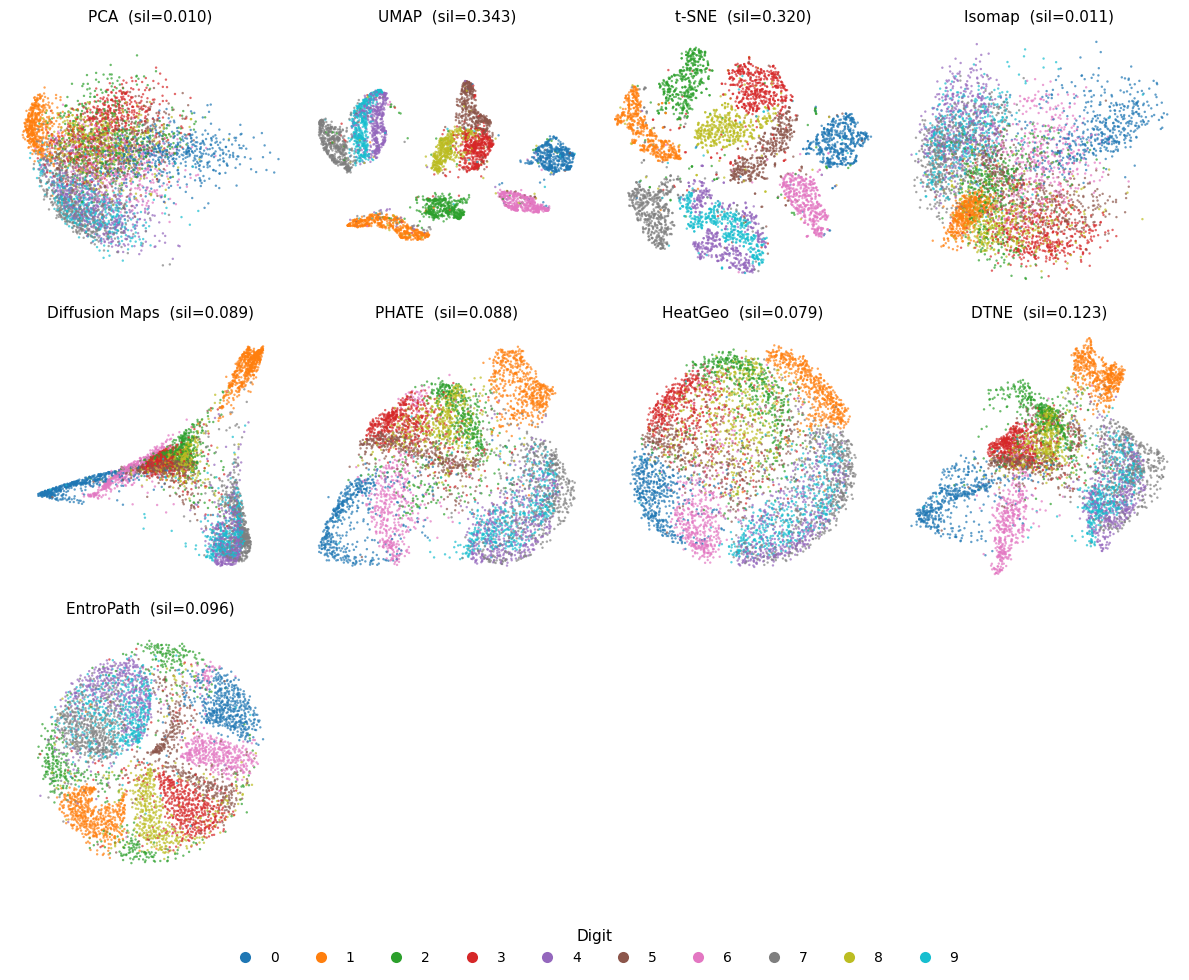

In [8]:
embedded_methods = [n for n in method_names_to_run if n in embeddings]
n_cols = 4
n_rows = -(-len(embedded_methods) // n_cols)

PANEL = 3.0
fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(PANEL * n_cols, PANEL * n_rows + 0.4))
axes = np.atleast_1d(axes).flatten()

# Discrete categorical palette for 10 digits — tab10 is the standard choice
cmap = plt.cm.tab10
norm = plt.Normalize(0, 9)

for ax, name in zip(axes, embedded_methods):
    emb = embeddings[name]
    ax.scatter(emb[:, 0], emb[:, 1],
               c=labels, cmap=cmap, norm=norm,
               s=3, alpha=0.7, linewidths=0, rasterized=True)
    ax.set_aspect("equal", adjustable="datalim")
    sil = silhouettes.get(name, np.nan)
    title = f"{name}  (sil={sil:.3f})" if not np.isnan(sil) else name
    ax.set_title(title, fontsize=11, pad=6)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)

for ax in axes[len(embedded_methods):]:
    ax.set_visible(False)

# Add a single shared legend for the digit classes
handles = [plt.Line2D([0], [0], marker="o", linestyle="",
                       markerfacecolor=cmap(i / 9), markeredgewidth=0,
                       markersize=8, label=str(i))
           for i in range(10)]
fig.legend(handles=handles, loc="upper center",
           bbox_to_anchor=(0.5, 0.02),
           ncol=10, title="Digit", fontsize=10, title_fontsize=11,
           frameon=False)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(FIGURES_DIR / "mnist_embeddings_grid.pdf", bbox_inches="tight")
plt.savefig(FIGURES_DIR / "mnist_embeddings_grid.png",
            dpi=300, bbox_inches="tight")
plt.show()


## Single-row figure — selected methods

Compact comparison of the most interesting methods, with digit labels overlaid at cluster centroids.

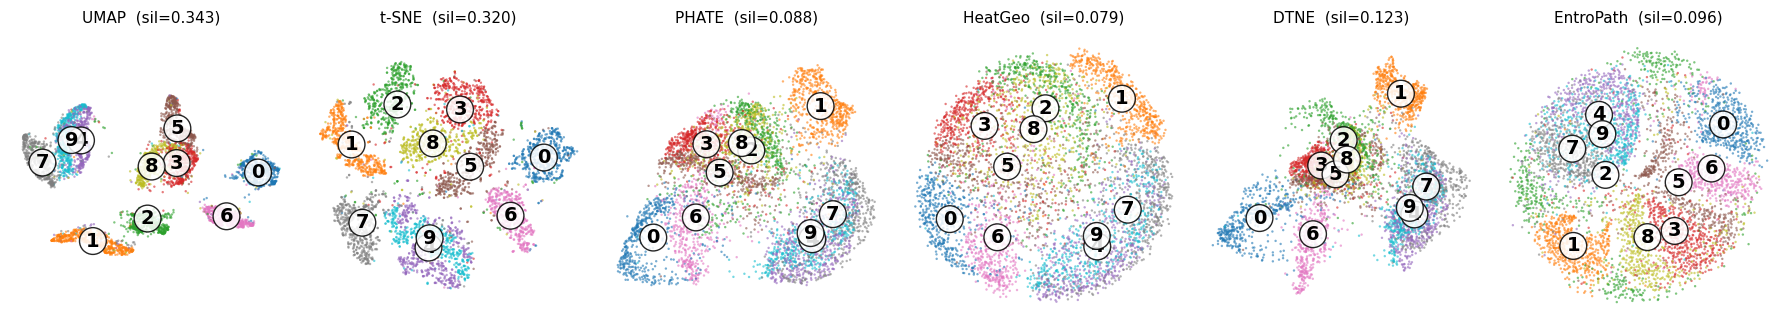

In [9]:
ROW_METHODS = ["UMAP", "t-SNE", "PHATE", "HeatGeo", "DTNE", "EntroPath"]
row_methods = [n for n in ROW_METHODS if n in embeddings]

fig, axes = plt.subplots(1, len(row_methods),
                         figsize=(PANEL * len(row_methods), PANEL + 0.4))
if len(row_methods) == 1:
    axes = [axes]

for ax, name in zip(axes, row_methods):
    emb = embeddings[name]
    ax.scatter(emb[:, 0], emb[:, 1],
               c=labels, cmap=cmap, norm=norm,
               s=3, alpha=0.6, linewidths=0, rasterized=True)
    # Digit labels at class centroids
    df_emb = pd.DataFrame(emb, columns=["x", "y"])
    centroids = df_emb.groupby(labels).mean()
    for digit, (cx, cy) in centroids.iterrows():
        ax.text(cx, cy, str(digit),
                fontsize=14, fontweight="bold",
                ha="center", va="center",
                bbox=dict(boxstyle="circle,pad=0.2",
                          facecolor="white", edgecolor="black",
                          alpha=0.85))
    sil = silhouettes.get(name, np.nan)
    title = f"{name}  (sil={sil:.3f})" if not np.isnan(sil) else name
    ax.set_title(title, fontsize=11, pad=6)
    ax.set_aspect("equal", adjustable="datalim")
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values():
        sp.set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "mnist_row_annotated.pdf", bbox_inches="tight")
plt.savefig(FIGURES_DIR / "mnist_row_annotated.png",
            dpi=300, bbox_inches="tight")
plt.show()


## Save results

In [10]:
import json

results = {
    "config": {
        "n_samples":   int(N_SAMPLES),
        "pca_dim":     int(PCA_DIM),
        "random_seed": int(RANDOM_SEED),
        "k_nn":        int(K_NN),
    },
    "silhouettes": silhouettes,
    "timings_seconds": timings,
}

with open(RESULTS_DIR / "mnist_silhouette.json", "w") as f:
    json.dump(results, f, indent=2)

# Save embeddings for later analysis without re-running
embedding_path = RESULTS_DIR / "mnist_embeddings.pkl"
with open(embedding_path, "wb") as f:
    pickle.dump(embeddings, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Saved silhouettes to mnist_silhouette.json")
print(f"Saved embeddings  to mnist_embeddings.pkl")


Saved silhouettes to mnist_silhouette.json
Saved embeddings  to mnist_embeddings.pkl
